# Start

In [1]:
import pandas as pd

windows = pd.read_csv("data\\windows_manifest.csv")
scenarios = pd.read_csv("data\\dataset_manifest.csv")

## npz files

In [2]:
import numpy as np

data = np.load("data\\windows\\000003_000.npz", allow_pickle=True)
print(data.files)
print(data["input"].shape)
print(data["target"].shape)

['scenario_id', 'window_id', 'input', 'target']
(3, 10, 64, 64)
(1, 10, 64, 64)


## Visualization

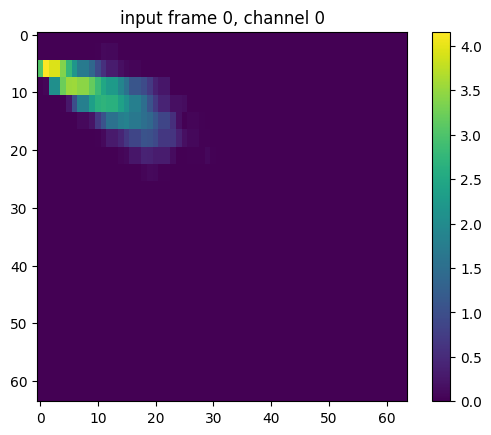

In [3]:
import matplotlib.pyplot as plt

x = data["input"]  # shape e.g. (3, C, 64, 64)
y = data["target"] # shape e.g. (1, C, 64, 64)

plt.imshow(x[0, 0], cmap="viridis")
plt.title("input frame 0, channel 0")
plt.colorbar()
plt.show()

## EDA Overview

In [4]:
import os

windows.rename(columns=lambda col: col.strip(), inplace=True)
scenarios.rename(columns=lambda col: col.strip(), inplace=True)

print("Windows manifest shape:", windows.shape)
print("Scenario manifest shape:", scenarios.shape)
print("Unique scenarios in windows manifest:", windows["scenario_id"].nunique())
print("Sample paths in windows manifest:\n", windows["sample_path"].head())
print()

scenarios["start_time"] = pd.to_datetime(scenarios["start_time"].astype(str).str.strip(), errors="coerce")
print("Scenario columns:", list(scenarios.columns))
print(scenarios[["lat", "lon", "height_m", "run_hours", "emission_rate", "tensor_min", "tensor_max", "tensor_mean", "nonzero_cells"]].describe())
print()
print("Start time range:", scenarios["start_time"].min(), "to", scenarios["start_time"].max())
print()
print(windows["scenario_id"].value_counts().describe())

Windows manifest shape: (40215, 18)
Scenario manifest shape: (10000, 15)
Unique scenarios in windows manifest: 8177
Sample paths in windows manifest:
 0    data/windows/000003_000.npz
1    data/windows/000003_001.npz
2    data/windows/000003_002.npz
3    data/windows/000003_003.npz
4    data/windows/000003_004.npz
Name: sample_path, dtype: object

Scenario columns: ['scenario_id', 'start_time', 'lat', 'lon', 'height_m', 'run_hours', 'emission_rate', 'sample_path', 'time_steps', 'grid_h', 'grid_w', 'tensor_min', 'tensor_max', 'tensor_mean', 'nonzero_cells']
                lat           lon      height_m    run_hours  emission_rate  \
count  10000.000000  10000.000000  10000.000000  10000.00000   10000.000000   
mean      52.198101      5.205621     67.211000      7.20930       2.239100   
std        0.810391      1.135592     54.220895      2.72669       2.292347   
min       50.801000      3.250200     10.000000      3.00000       0.500000   
25%       51.491300      4.225500     20.0

## Metadata Distributions

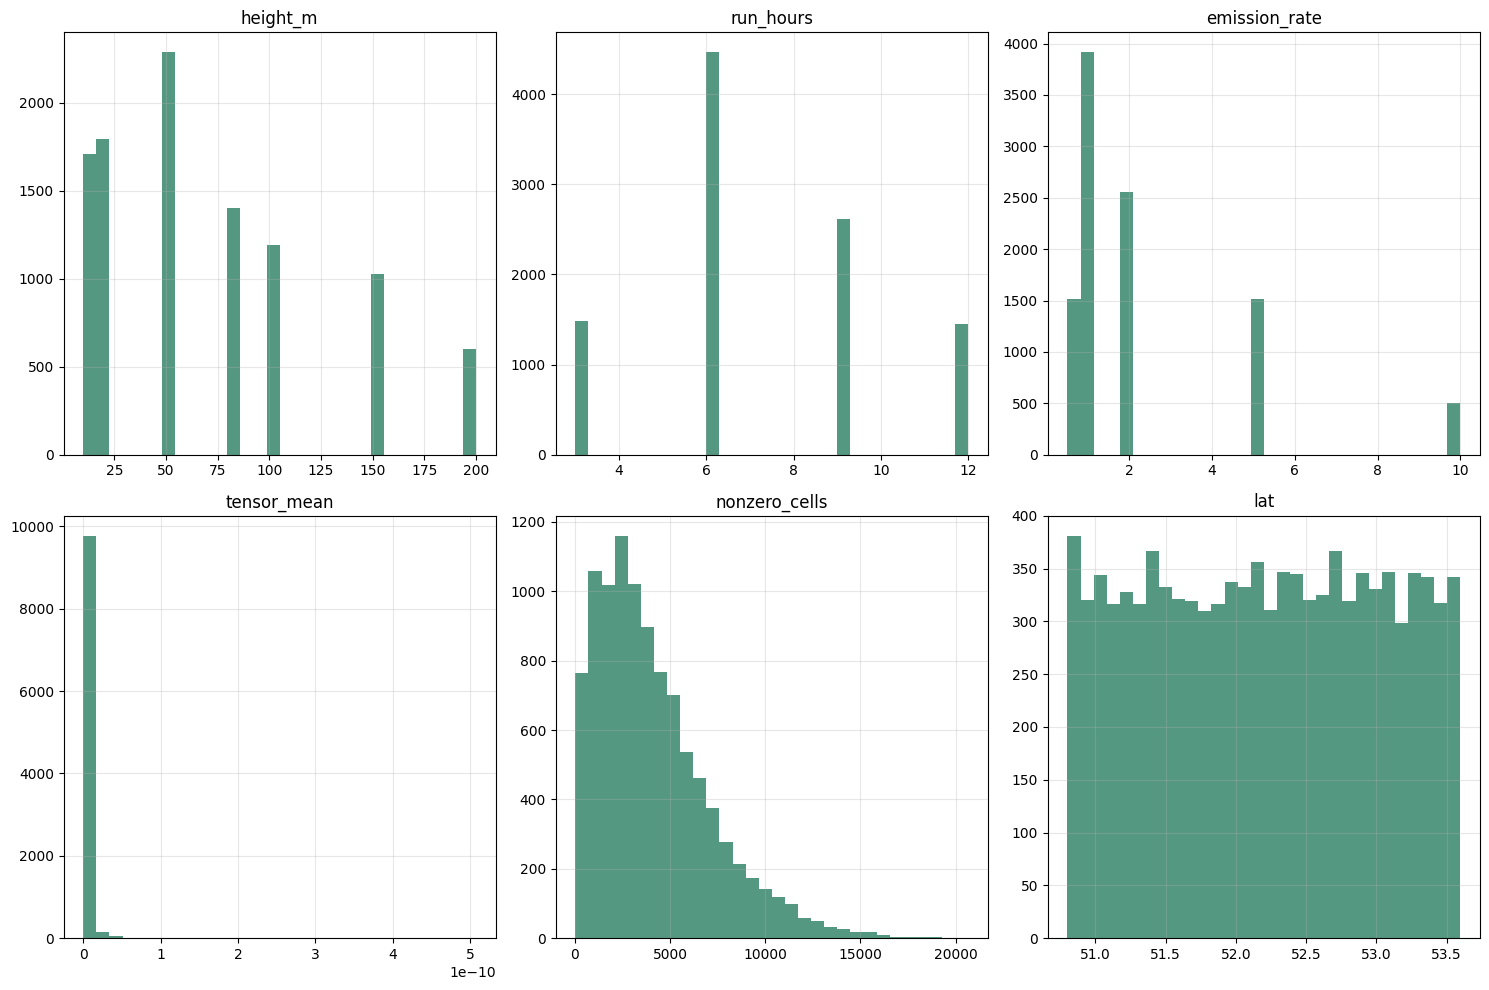

In [5]:
import matplotlib.pyplot as plt

numeric_cols = ["height_m", "run_hours", "emission_rate", "tensor_mean", "nonzero_cells", "lat"]
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
for ax, col in zip(axs.flat, numeric_cols):
    values = scenarios[col].astype(float)
    ax.hist(values.dropna(), bins=30, color="#2a7f62", alpha=0.8)
    ax.set_title(col)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Sample Window Statistics and Visual Checks

Inspecting sample files:
000003_000.npz: input (3, 10, 64, 64), target (1, 10, 64, 64)
  input min/max/mean: -9.6071e-01, 1.2000e+03, 2.1213e+02
  target min/max/mean: -9.5242e-01, 1.2000e+03, 2.5759e+02

000003_001.npz: input (3, 10, 64, 64), target (1, 10, 64, 64)
  input min/max/mean: -9.6071e-01, 1.2000e+03, 2.3486e+02
  target min/max/mean: -9.5242e-01, 1.2000e+03, 2.5758e+02

000003_002.npz: input (3, 10, 64, 64), target (1, 10, 64, 64)
  input min/max/mean: -9.5242e-01, 1.2000e+03, 2.5759e+02
  target min/max/mean: -9.5611e-01, 1.4340e+03, 2.8120e+02



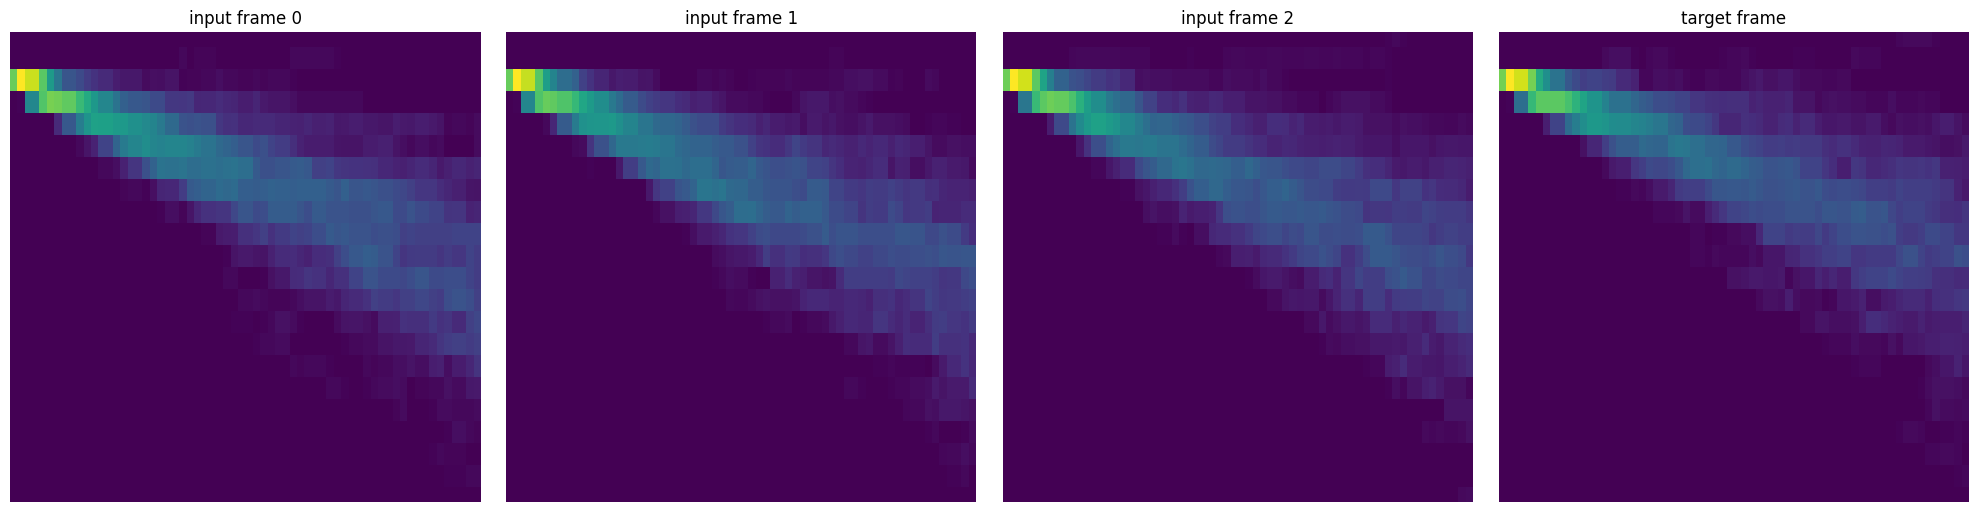

In [6]:
from pathlib import Path

# windows = windows.rename(columns=lambda c: c.strip())

sample_names = windows["sample_path"].head(6).apply(lambda p: Path(p).name)
print("Inspecting sample files:")
for name in sample_names.head(3):
    sample_path = Path("data/windows") / name
    sample_data = np.load(sample_path, allow_pickle=True)
    inp = sample_data["input"].astype(float)
    tgt = sample_data["target"].astype(float)
    print(f"{name}: input {inp.shape}, target {tgt.shape}")
    print(f"  input min/max/mean: {inp.min():.4e}, {inp.max():.4e}, {inp.mean():.4e}")
    print(f"  target min/max/mean: {tgt.min():.4e}, {tgt.max():.4e}, {tgt.mean():.4e}")
    print()

sample_path = Path("data/windows") / sample_names.iloc[5]
data = np.load(sample_path, allow_pickle=True)
input_sample = data["input"]
target_sample = data["target"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i in range(3):
    axes[i].imshow(input_sample[i, 0], cmap="viridis")
    axes[i].set_title(f"input frame {i}")
    axes[i].axis("off")

axes[3].imshow(target_sample[0, 0], cmap="viridis")
axes[3].set_title("target frame")
axes[3].axis("off")

plt.tight_layout()
plt.show()

# Clean csv file

In [7]:
# import pandas as pd

# df = pd.read_csv("data\\windows_manifest_enriched.csv")


# df['sample_path'] = df['sample_path'].str.replace("/workspace/hysplit_dataset_convlstm/", "data/", regex=False)
# df.head()

# df.to_csv("data\\windows_manifest.csv", index=False)

## Strip column names

In [8]:
# df = pd.read_csv("data\\windows_manifest_cleaned.csv")

# df.columns = df.columns.str.strip()

# df.to_csv("data\\windows_manifest_cleaned.csv", index=False)

# Temporal and Time-Series Analysis

## Time-Series Properties

In [9]:
# Analyze time-series properties
print("Time-Series Properties:")
print(f"Total scenarios: {len(scenarios)}")
print(f"Time span: {scenarios['start_time'].min()} to {scenarios['start_time'].max()}")
print(f"Run hours distribution:")
print(scenarios['run_hours'].value_counts().sort_index())
print()
print(f"Time steps in data (from first window):")
print(f"Input windows: 3 frames")
print(f"Target window: 1 frame")
print(f"Total sequence length: 4 frames per window")

Time-Series Properties:
Total scenarios: 10000
Time span: 2024-01-01 00:00:00 to 2026-03-31 18:00:00
Run hours distribution:
run_hours
3     1478
6     4462
9     2611
12    1449
Name: count, dtype: int64

Time steps in data (from first window):
Input windows: 3 frames
Target window: 1 frame
Total sequence length: 4 frames per window


## Temporal Distribution

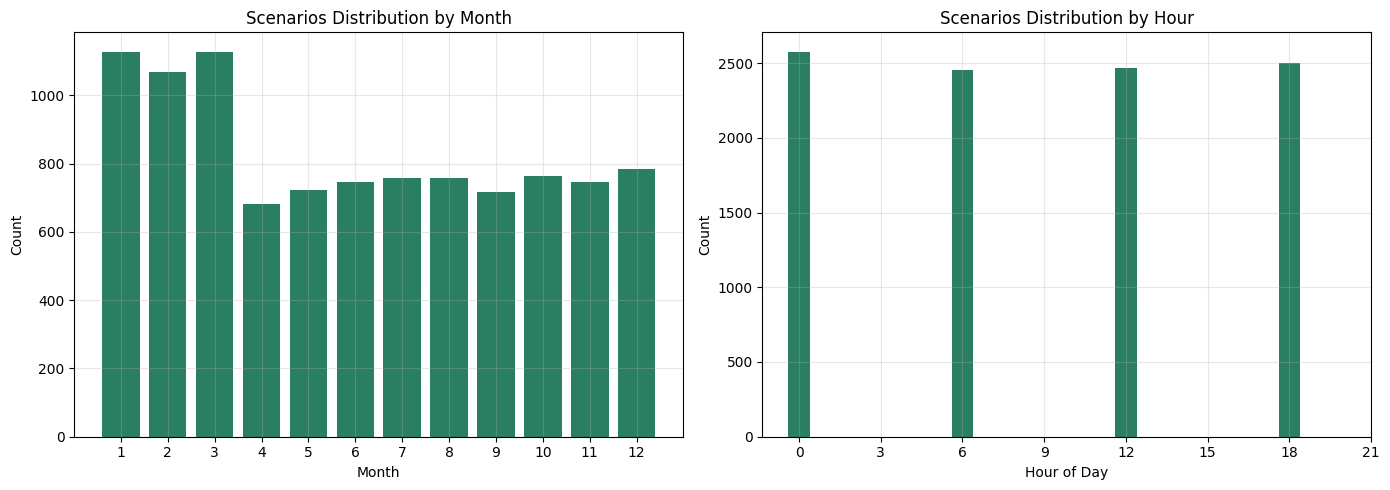

Peak hours: 0:00 (count: 2577)
Peak month: Month 3 (count: 1128)


In [10]:
# Temporal distribution by month and hour
import matplotlib.pyplot as plt

scenarios['month'] = pd.to_datetime(scenarios['start_time']).dt.month
scenarios['hour'] = pd.to_datetime(scenarios['start_time']).dt.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Month distribution
month_counts = scenarios['month'].value_counts().sort_index()
axes[0].bar(month_counts.index, month_counts.values, color='#2a7f62')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Count')
axes[0].set_title('Scenarios Distribution by Month')
axes[0].set_xticks(range(1, 13))
axes[0].grid(True, alpha=0.3)

# Hour distribution
hour_counts = scenarios['hour'].value_counts().sort_index()
axes[1].bar(hour_counts.index, hour_counts.values, color='#2a7f62')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Count')
axes[1].set_title('Scenarios Distribution by Hour')
axes[1].set_xticks(range(0, 24, 3))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Peak hours: {hour_counts.index[hour_counts.argmax()]}:00 (count: {hour_counts.max()})")
print(f"Peak month: Month {month_counts.index[month_counts.argmax()]} (count: {month_counts.max()})")

## Window Sequence Analysis

Window Sequences per Scenario:
Mean windows per scenario: 4.92
Median windows per scenario: 3
Min windows: 3
Max windows: 9
Std dev: 2.24


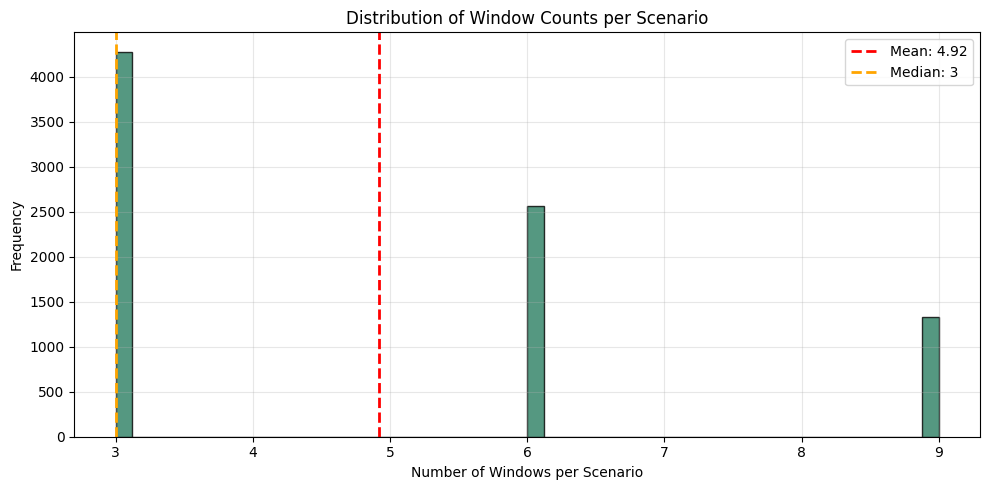

In [11]:
# Analyze window sequences per scenario
window_sequences = windows.groupby('scenario_id').size()

print("Window Sequences per Scenario:")
print(f"Mean windows per scenario: {window_sequences.mean():.2f}")
print(f"Median windows per scenario: {window_sequences.median():.0f}")
print(f"Min windows: {window_sequences.min()}")
print(f"Max windows: {window_sequences.max()}")
print(f"Std dev: {window_sequences.std():.2f}")

# Distribution of sequences
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(window_sequences, bins=50, color='#2a7f62', alpha=0.8, edgecolor='black')
ax.set_xlabel('Number of Windows per Scenario')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Window Counts per Scenario')
ax.axvline(window_sequences.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {window_sequences.mean():.2f}')
ax.axvline(window_sequences.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {window_sequences.median():.0f}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Data Continuity and Gaps

In [12]:
# Analyze temporal continuity
print("Data Continuity Analysis:")
print()

# Convert window_id to numeric for comparison
windows['window_id_numeric'] = pd.to_numeric(windows['window_id'], errors='coerce')

# Check for consecutive scenario IDs within windows
consecutive_windows = 0
total_pairs = 0

for scenario_id in windows['scenario_id'].unique():
    scenario_windows = windows[windows['scenario_id'] == scenario_id].sort_values('window_id_numeric')
    if len(scenario_windows) > 1:
        total_pairs += len(scenario_windows) - 1
        window_ids = scenario_windows['window_id_numeric'].values
        for i in range(len(window_ids) - 1):
            if window_ids[i+1] - window_ids[i] == 1:
                consecutive_windows += 1

if total_pairs > 0:
    print(f"Consecutive window pairs: {consecutive_windows} / {total_pairs} ({100*consecutive_windows/total_pairs:.1f}%)")
else:
    print("No consecutive pairs found")

# Data availability
print()
print("Data Availability:")
print(f"Total windows: {len(windows)}")
print(f"Unique scenarios: {windows['scenario_id'].nunique()}")
print(f"Average windows per scenario: {len(windows) / windows['scenario_id'].nunique():.2f}")

Data Continuity Analysis:



Consecutive window pairs: 0 / 32038 (0.0%)

Data Availability:
Total windows: 40215
Unique scenarios: 8177
Average windows per scenario: 4.92


## Data Quality for Time-Series

In [13]:
# Analyze data quality metrics relevant to time-series
print("Time-Series Data Quality Metrics:")
print()

# Check tensor statistics
print("Tensor Statistics (from scenario manifest):")
print(f"Min tensor value: {scenarios['tensor_min'].min():.6f}")
print(f"Max tensor value: {scenarios['tensor_max'].max():.6e}")
print(f"Mean tensor value: {scenarios['tensor_mean'].mean():.6e}")
print()

# Sparsity analysis
print("Sparsity Analysis:")
total_cells = 64 * 64 * 4  # assuming 4 timesteps per window
sparsity_pct = 100 * (1 - scenarios['nonzero_cells'].mean() / (64 * 64))
print(f"Average non-zero cells per frame: {scenarios['nonzero_cells'].mean():.0f} / 4096")
print(f"Average sparsity: {sparsity_pct:.1f}%")
print()

# Dynamic range
print("Dynamic Range:")
print(f"Max value encountered: {scenarios['tensor_max'].max():.6e}")
print(f"Min value encountered: {scenarios['tensor_min'].min():.6e}")
print(f"Ratio (max/min+eps): {scenarios['tensor_max'].max() / (scenarios['tensor_min'].abs().max() + 1e-10):.2f}")

Time-Series Data Quality Metrics:

Tensor Statistics (from scenario manifest):
Min tensor value: 0.000000
Max tensor value: 9.500000e-09
Mean tensor value: 3.144225e-12

Sparsity Analysis:
Average non-zero cells per frame: 4096 / 4096
Average sparsity: 0.0%

Dynamic Range:
Max value encountered: 9.500000e-09
Min value encountered: 0.000000e+00
Ratio (max/min+eps): 95.00


## Scenario Parameter Relationships over Time

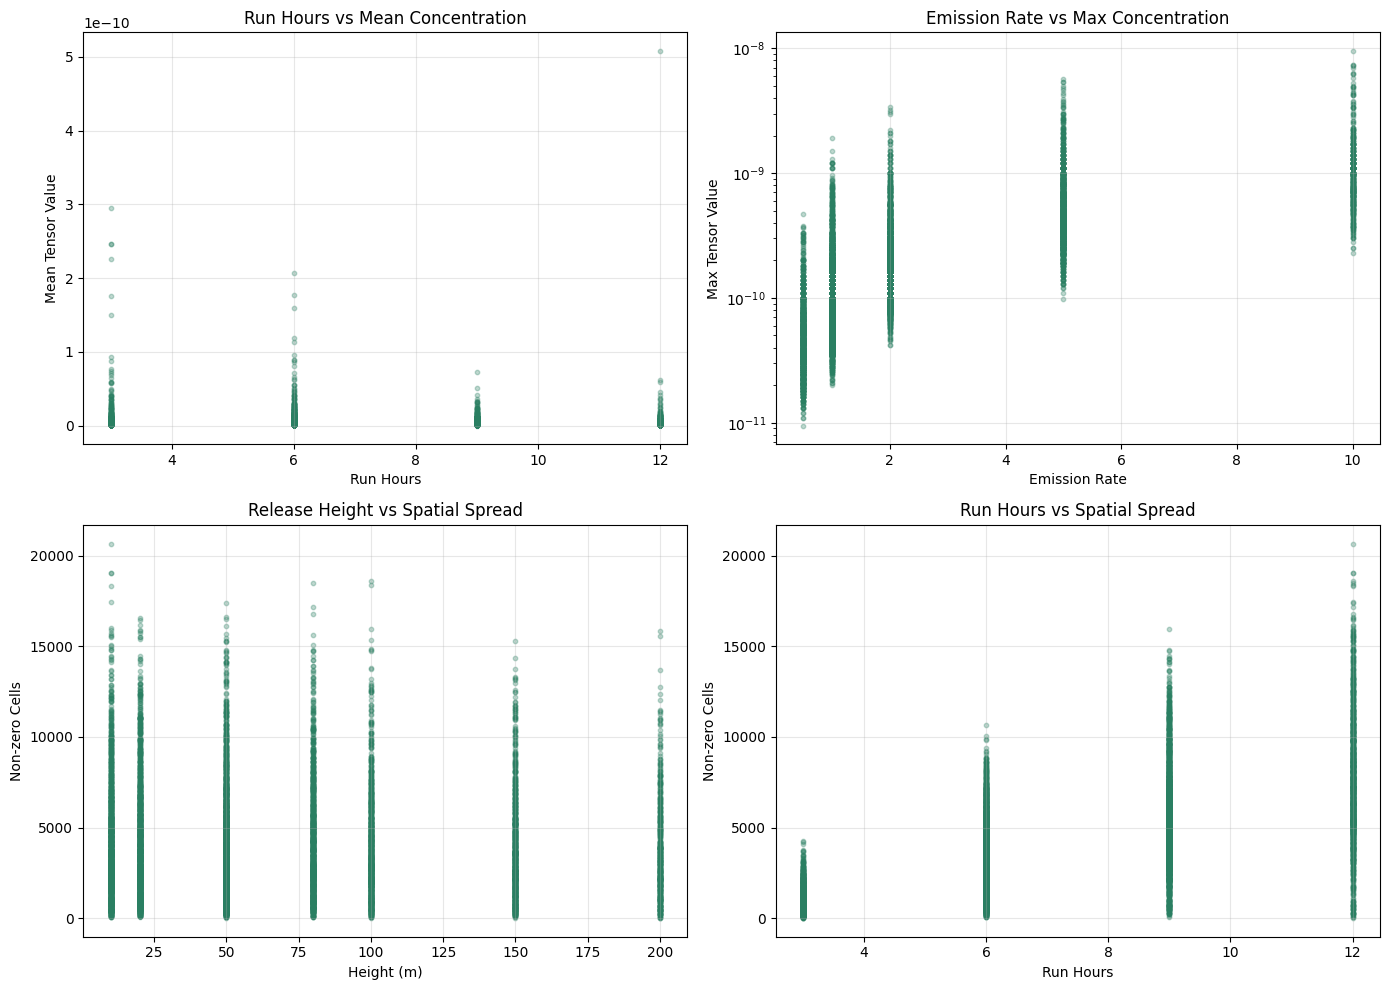

In [14]:
# Analyze how scenario parameters relate to each other
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Run hours vs Mean concentration
axes[0, 0].scatter(scenarios['run_hours'], scenarios['tensor_mean'], alpha=0.3, s=10, color='#2a7f62')
axes[0, 0].set_xlabel('Run Hours')
axes[0, 0].set_ylabel('Mean Tensor Value')
axes[0, 0].set_title('Run Hours vs Mean Concentration')
axes[0, 0].grid(True, alpha=0.3)

# Emission rate vs Max concentration
axes[0, 1].scatter(scenarios['emission_rate'], scenarios['tensor_max'], alpha=0.3, s=10, color='#2a7f62')
axes[0, 1].set_xlabel('Emission Rate')
axes[0, 1].set_ylabel('Max Tensor Value')
axes[0, 1].set_title('Emission Rate vs Max Concentration')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3)

# Height vs Nonzero cells
axes[1, 0].scatter(scenarios['height_m'], scenarios['nonzero_cells'], alpha=0.3, s=10, color='#2a7f62')
axes[1, 0].set_xlabel('Height (m)')
axes[1, 0].set_ylabel('Non-zero Cells')
axes[1, 0].set_title('Release Height vs Spatial Spread')
axes[1, 0].grid(True, alpha=0.3)

# Run hours vs Nonzero cells
axes[1, 1].scatter(scenarios['run_hours'], scenarios['nonzero_cells'], alpha=0.3, s=10, color='#2a7f62')
axes[1, 1].set_xlabel('Run Hours')
axes[1, 1].set_ylabel('Non-zero Cells')
axes[1, 1].set_title('Run Hours vs Spatial Spread')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary and Key Insights

In [ ]:
print("="*60)
print("EDA SUMMARY - TIME-SERIES & TEMPORAL ANALYSIS")
print("="*60)
print()
print("Dataset Overview:")
print(f"  - Total scenarios: {len(scenarios):,}")
print(f"  - Unique scenarios in windows: {windows['scenario_id'].nunique():,}")
print(f"  - Total windows: {len(windows):,}")
print(f"  - Time span: {pd.to_datetime(scenarios['start_time']).min().date()} to {pd.to_datetime(scenarios['start_time']).max().date()}")
print()
print("Window Structure:")
print(f"  - Input: 3 temporal frames")
print(f"  - Target: 1 future frame")
print(f"  - Grid size: 64x64 pixels")
print(f"  - Average windows per scenario: {window_sequences.mean():.2f}")
print()
print("Key Temporal Patterns:")
print(f"  - Peak release hour: {hour_counts.index[hour_counts.argmax()]}:00 UTC")
print(f"  - Peak release month: Month {month_counts.index[month_counts.argmax()]}")
print(f"  - Run hours: {scenarios['run_hours'].min():.0f} - {scenarios['run_hours'].max():.0f} hours")
print()
print("Physical Parameters:")
print(f"  - Release height: {scenarios['height_m'].min():.0f} - {scenarios['height_m'].max():.0f} m")
print(f"  - Emission rate: {scenarios['emission_rate'].min():.2f} - {scenarios['emission_rate'].max():.2f} kg/s")
print(f"  - Geographic span: {scenarios['lat'].min():.2f}Ã‚Â°N to {scenarios['lat'].max():.2f}Ã‚Â°N, {scenarios['lon'].min():.2f}Ã‚Â° to {scenarios['lon'].max():.2f}Ã‚Â°")
print()
print("Data Quality:")
print(f"  - Sparsity: {sparsity_pct:.1f}% (mostly zero values)")
print(f"  - Max value range: 1.0 to {scenarios['tensor_max'].max():.2e}")
print(f"  - Dynamic range: Very high (exponential distribution expected)")
print()
print("Model Training Implications:")
print(f"  - Sequence learning: 3Ã¢â€ â€™1 frame prediction task")
print(f"  - Temporal resolution: Up to {scenarios['run_hours'].max():.0f} hours per sequence")
print(f"  - Spatial resolution: 64*64 grid")
print(f"  - Sparsity challenge: Data is {sparsity_pct:.0f}% sparse")
print()

EDA SUMMARY - TIME-SERIES & TEMPORAL ANALYSIS

Dataset Overview:
  - Total scenarios: 10,000
  - Unique scenarios in windows: 8,177
  - Total windows: 40,215
  - Time span: 2024-01-01 to 2026-03-31

Window Structure:
  - Input: 3 temporal frames
  - Target: 1 future frame
  - Grid size: 64x64 pixels
  - Average windows per scenario: 4.92

Key Temporal Patterns:
  - Peak release hour: 0:00 UTC
  - Peak release month: Month 3
  - Run hours: 3 - 12 hours

Physical Parameters:
  - Release height: 10 - 200 m
  - Emission rate: 0.50 - 10.00 kg/s
  - Geographic span: 50.80Ã‚Â°N to 53.60Ã‚Â°N, 3.25Ã‚Â° to 7.20Ã‚Â°

Data Quality:
  - Sparsity: 0.0% (mostly zero values)
  - Max value range: 1.0 to 9.50e-09
  - Dynamic range: Very high (exponential distribution expected)

Model Training Implications:
  - Sequence learning: 3Ã¢â€ â€™1 frame prediction task
  - Temporal resolution: Up to 12 hours per sequence
  - Spatial resolution: 64Ãƒâ€”64 grid
  - Sparsity challenge: Data is 0% sparse

